# Multiaxial Plastic Analysis

In [ ]:
try:
    from veux.canvas.config import beamer
except:
    pass

from xsection.library import from_aisc, aisc_data
import matplotlib.pyplot as plt

import numpy as np

## Geometry and Material

In [2]:
from math import sqrt
from xara.units.iks import inch, foot, ksi, kip

In [3]:
import xara 

E = 29e3*ksi
v = 0.3
# Shear modulus
G = E/(2.0*(1.0+v))
# Yield stress
Fy = 60.0*ksi

# Define materials
material = xara.MultiaxialMaterial(
        "NonlinearJ2", #"J2BeamThread", #
        E=E, 
        nu=v, 
        Fy=Fy,
        Hiso=0.0001*E, 
        Hkin=0.000*E,
        # Fs=sig0,
        # tol=1e-10,
)

Under multiaxial plasticity, the limit stress in pure shear is given by 
$$
F_{\mathrm{sh}} = \frac{1}{\sqrt3} F_y
$$

In [4]:

Fsh = sqrt(1/3) * Fy

In [5]:
# Create the shape
shape_name = "W8X40"
# shape_name = "W14x132"

shape = from_aisc(shape_name,
                  material=material, 
                  mesh_type="T3",
                  mesher="gmsh",
                  fillet=False,
                  mesh_scale=1 #0.8
                  )

In [6]:
data = aisc_data(shape_name)

Z = data["Zx"] * inch**3
My = Fy*data["Sx"] * inch**3
A = data["A"] * inch**2
J = data["J"] * inch**4


Aweb = shape.d * shape.tw

Vy = Fsh * Aweb
Ty = 0.6 * Fy * J

print(f"{Vy = }")
print(f"{A/Aweb = }")
data

Vy = 102.88381796959129
A/Aweb = 3.9393939393939394


{'A': 11.7,
 'Ix': 146.0,
 'Iy': 49.1,
 'J': 1.12,
 'Cw': 726.0,
 'Zx': 39.8,
 'Zy': 18.5,
 'Sx': 35.5,
 'Sy': 12.2,
 'rx': 3.53,
 'ry': 2.04,
 'd': 8.25,
 'bf': 8.07,
 'tw': 0.36,
 'tf': 0.56,
 'kdes': 0.954}

In [7]:
Cv1 = 1.0
Vn = 0.6 * Fy * Aweb * Cv1

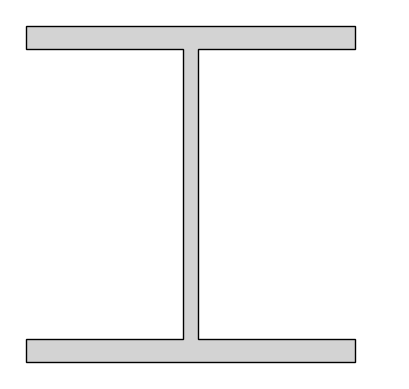

In [8]:
import veux
veux.draw_shape(shape)

In [10]:
Sections = {
    "MultiaxialFiber": xara.Section("MultiaxialFiber", shape, mixed_type="UE"),
    "NDFiber":         xara.Section("NDFiber", shape, mixed_type="UE"),
    # "UG": xara.Section("MultiaxialFiber", shape, mixed_type="UG"),
}

## Interaction Analysis


  0%|          | 0/60 [00:00<?, ?it/s]

 18%|█▊        | 11/60 [00:02<00:08,  5.85it/s]

Analysis failed at step 208 with flags -3 and -3


 38%|███▊      | 23/60 [00:04<00:06,  5.89it/s]

Recovery successful


...

 67%|██████▋   | 40/60 [00:05<00:02,  8.02it/s]

Recovery successful


 87%|████████▋ | 52/60 [00:06<00:00,  8.21it/s]

Recovery successful


100%|██████████| 60/60 [00:07<00:00,  7.63it/s]


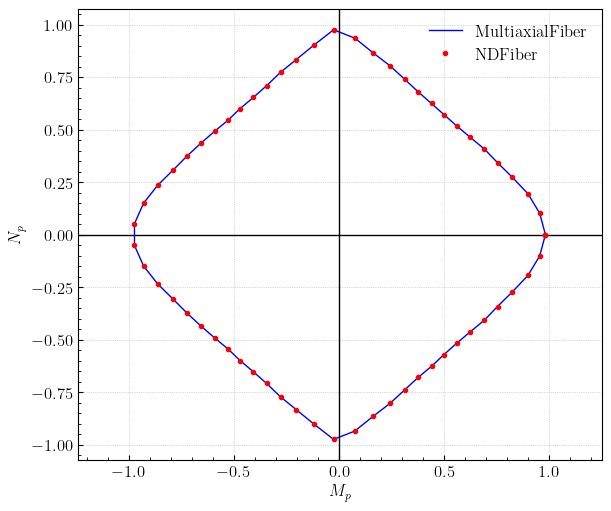

In [11]:
from xsection.analysis import PlasticContour, PlasticLimit
from xsection.analysis.interaction.shear import _get_fibers

#
# Setup the interaction analysis
#


colors = iter(["blue", "red", "green"])
lines = iter(["-", ".", "--"])
fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 5))
ax.axvline(0, color="black", ls="-", lw=1)
ax.axhline(0, color="black", ls="-", lw=1)


# Run the analysis for each section
for label, section in Sections.items():
    color = next(colors)
    si = PlasticContour(section,
                        Fj=A*Fy, dof_j="N",
                        Fi=Z*Fy, dof_i="My",
                        overstress=1.1,
                        limit_tol=0.9,
                        limit_state="plastic",
                        limit_stress=Fy,
                        sweep_steps=60
    )
    ax.plot(*np.array(list(si.run())).T, next(lines), label=label, color=color)

ax.axis("equal")
ax.grid(True)
ax.legend()
ax.set_ylabel("$N_p$")
ax.set_xlabel("$M_p$");

The moment-axial force interaction is identical between `MultiaxialFiber` and `NDFiber` section.


### Moment-Shear 

100%|██████████| 50/50 [00:04<00:00, 12.15it/s]


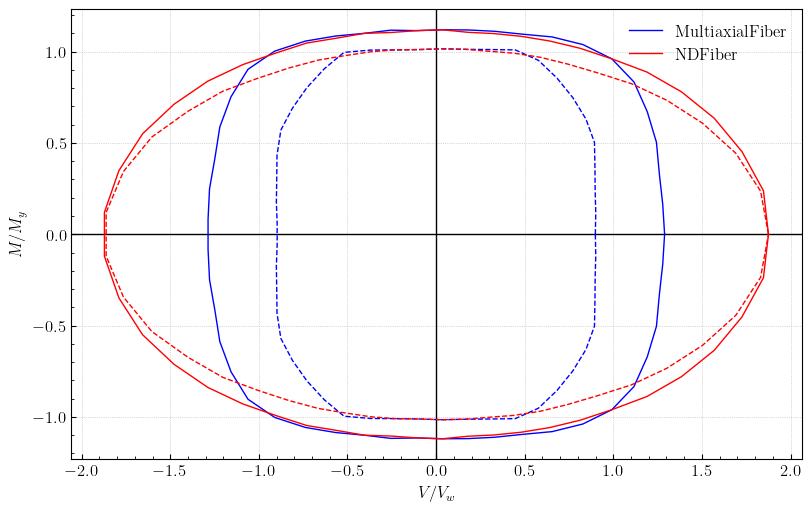

In [12]:

#
# Setup the interaction analysis
#


fig, ax = plt.subplots(constrained_layout=True, figsize=(8, 5))
# ax.axvline(Fsh*A/Vy, color="black", ls="--", lw=1)
ax.axvline(0, color="black", ls="-", lw=1)
ax.axhline(0, color="black", ls="-", lw=1)


colors = iter(["blue", "red", "green"])
for label, section in Sections.items():
    color = next(colors)
    si = PlasticContour(section, 
                        Fi=Vy, dof_i="Vz",
                        Fj=My, dof_j="My",
                        overstress=shape.area/Aweb,
                        limit_tol=0.99,
                        limit_state="plastic",
                        limit_stress=Fy)
    ax.plot(*np.array(list(si.run())).T, label=label, color=color)
    si = PlasticContour(section, 
                        Fi=Vy, dof_i="Vz",
                        Fj=My, dof_j="My",
                        overstress=shape.area/Aweb,
                        steps=400,
                        limit_state="elastic",
                        limit_stress=Fy)
    ax.plot(*np.array(list(si.run())).T, "--",  color=color)


ax.grid(True)
ax.legend()
ax.set_xlabel("$V/V_{w}$")
ax.set_ylabel("$M/M_{y}$");

- When `NDFiber` is loaded in pure shear, all fibers go plastic at the same time. `MultiaxialFiber` exhibits a gradual transition to the plastic shear
- In the state of ultimate plastic shear, `NDFiber` produces a uniform stress field $\boldsymbol{\sigma} = (0, 0, F_{\mathrm{sh}})$, but the resultant is not $\int F_{\mathrm{sh}}\, dA$

In [13]:
# fig, ax = plt.subplots(constrained_layout=True, figsize=(10, 5))
# section = xara.Section("MultiaxialFiber", shape)
# si = PlasticContour(section, Fi=Vy, Fj=Z*sig0, 
#                         limit_stress=sig0, Fo=Ty, dof_o="T")
# ax.plot(*np.array(list(si.run())).T);


# section = xara.Section("NDFiber", shape)
# si = PlasticContour(section, Fi=Vy, Fj=Z*sig0, 
#                         limit_stress=sig0, Fo=Ty, dof_o="T")
# ax.plot(*np.array(list(si.run())).T);

# ax.set_xlabel("$V_p$")
# ax.set_ylabel("$M_p$");

In [14]:

# fig, ax = plt.subplots(constrained_layout=True, figsize=(10, 5))


# section = xara.Section("MultiaxialFiber", shape)
# si = PlasticContour(section, Fi=Vy, Fj=Z*sig0, 
#                         limit_state="elastic",
#                         limit_stress=sig0)
# ax.plot(*np.array(list(si.run())).T);


# section = xara.Section("NDFiber", shape)
# si = PlasticContour(section, Fi=Vy, Fj=Z*sig0, 
#                         limit_state="elastic",
#                         limit_stress=sig0)
# ax.plot(*np.array(list(si.run())).T);

## Limits

1.0010000345018233
1.001000000000051
1.0010000345017744
1.0010000000000001


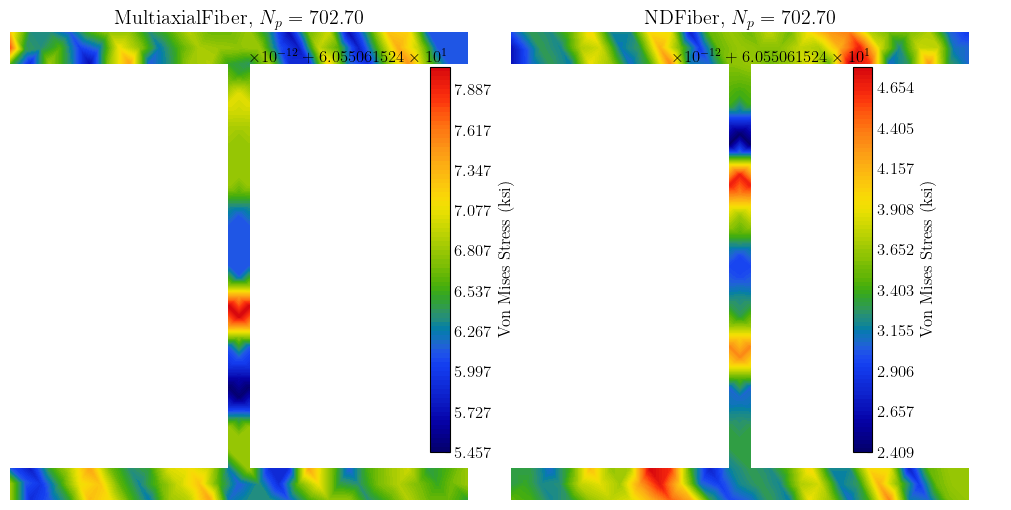

In [15]:
from xara.post import FiberStress, NodalAverage
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [A*Fy,0,0,  0, 0, 0], Fy, overstress=1.1)

    Np = 0
    for j, f in _get_fibers(pl.model, 1).items():
        Np += pl.model.eleResponse(1, "section", "fiber", j, "stress")[0]*f["area"]
    print(Np/(A*Fy))
    print(pl.resultant[0]/(A*Fy))

    ax[i].set_title(label + f", $N_p = {-pl.reaction[0]:.2f}$")


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1

### Moment

0.9900001264506103
-0.9900000000000011
0.9900001264506092
-0.9899999999999998


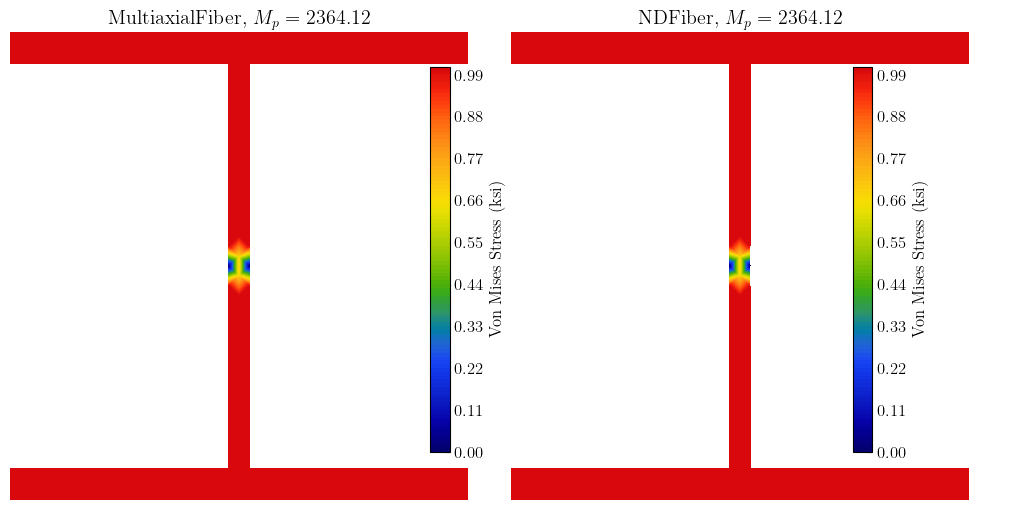

In [16]:
from xara.post import FiberStress, NodalAverage
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [0,0,0,  0, Z*Fy, 0], Fy, overstress=1.1)

    Mp = 0
    for j, f in _get_fibers(pl.model, 1).items():
        z = f.get("coord", f.get("location",[None,f.get("z",None)]))[1]
        Mp += pl.model.eleResponse(1, "section", "fiber", j, "stress")[0]*f["area"]*z
    print(Mp/(Z*Fy))
    print(pl.reaction[4]/(Z*Fy))

    ax[i].set_title(label + f", $M_p = {-pl.reaction[4]:.2f}$")

    if i > 1:
        continue


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1, scale=1/Fy)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1

### Shear

Vn =  106.91999999999999
Vp =  405.29988897111724
V =  133.748970098561
R =  133.74896336046854
V =  405.5282724721839
R =  194.5439467061315


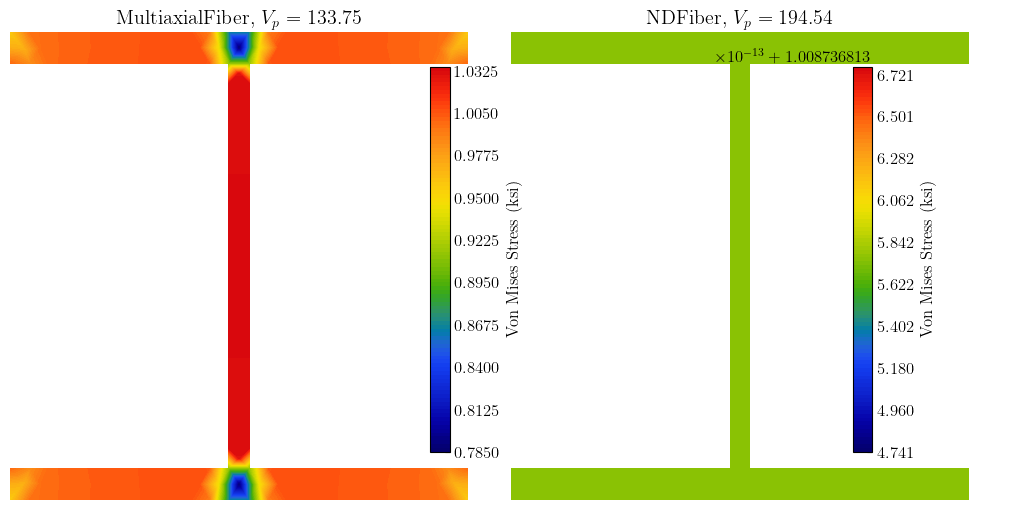

In [17]:

fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

print("Vn = ", Vn)
print("Vp = ", Fsh*A)
# section = xara.Section("NDFiber", shape, mixed_type="UE")
i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [0, 0, Vy, 0, 0, 0], Fy, overstress=A/Aweb)

    Vp = 0
    for j, f in _get_fibers(pl.model, 1).items():
        Vp += pl.model.eleResponse(1, "section", "fiber", j, "stress")[2]*f["area"]
    print("V = ", Vp)
    print("R = ", -pl.reaction[2])


    if i > 1:
        continue

    ax[i].set_title(label + f", $V_p = {-pl.reaction[2]:.2f}$")


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1, scale=1/Fy)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1

0.9310844511541564
-0.9310843294529599
0.9310844511541473
-0.9310843294529504


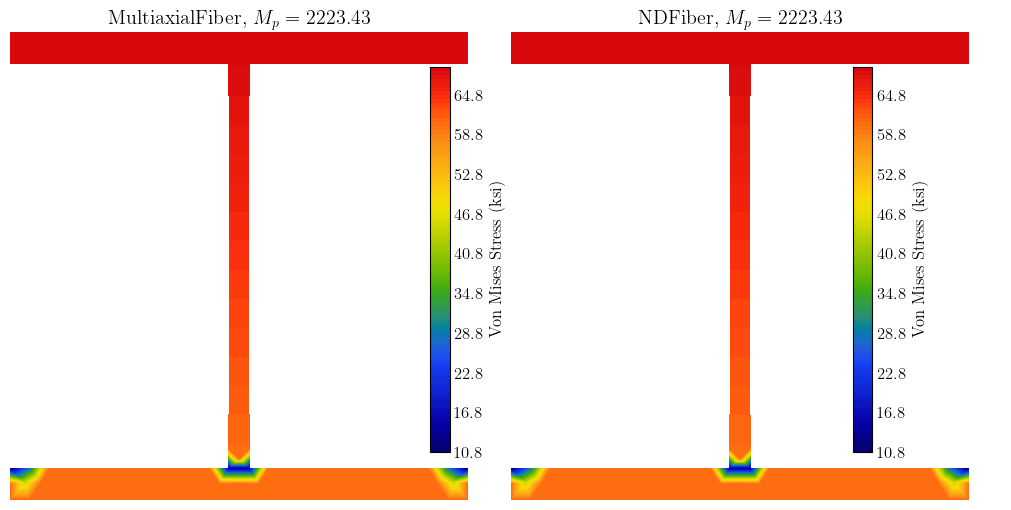

In [18]:

fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

a = np.pi/10
i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [A*Fy*np.sin(a),0,0,  
                                0, Z*Fy*np.cos(a), 0], 
                                Fy, overstress=1.1)

    Mp = 0
    for j, f in _get_fibers(pl.model, 1).items():
        z = f.get("coord", f.get("location",[None,f.get("z",None)]))[1]
        Mp += pl.model.eleResponse(1, "section", "fiber", j, "stress")[0]*f["area"]*z
    print(Mp/(Z*Fy))
    print(pl.reaction[4]/(Z*Fy))
    if i > 1:
        continue

    ax[i].set_title(label + f", $M_p = {-pl.reaction[4]:.2f}$")


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1